# 01 – Geodaten: Ortsteile, Stadtbezirke und die Linie 8

In diesem Notebook schauen wir uns die räumliche Grundlage des Projekts an:

1. Was steckt in den Dateien `ortsteile.geojson` und `stadtbezirke.geojson`?
2. Wie hängen Ortsteile und Stadtbezirke zusammen?
3. Wo liegen sie auf der Karte?
4. Welche Ortsteile durchfährt die Straßenbahnlinie 8?

Voraussetzung: Die Rohdaten liegen in `data/raw/` (siehe README).

In [1]:
import zipfile
from pathlib import Path

import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString

pd.set_option("display.max_rows", 100)

RAW = Path("data/raw")

## 1. Die Dateien laden

Beide Dateien sind GeoJSON. `geopandas` liest sie als **GeoDataFrame**: eine normale Tabelle mit einer zusätzlichen Spalte `geometry`, in der die Fläche jedes Gebiets steckt.

In [2]:
ortsteile = gpd.read_file(RAW / "geodaten/ortsteile.geojson")
bezirke = gpd.read_file(RAW / "geodaten/stadtbezirke.geojson")

print(f"{len(ortsteile)} Ortsteile, {len(bezirke)} Stadtbezirke")
ortsteile.head()

63 Ortsteile, 10 Stadtbezirke


,FID,OT,Name,geometry
0,0,00,Zentrum,"POLYGON ((317483.317 5691380.912, 317472.492 5..."
1,1,01,Zentrum-Ost,"POLYGON ((318071.542 5690670.374, 318096.179 5..."
2,2,02,Zentrum-Südost,"POLYGON ((318544.743 5690680.07, 318550.703 56..."
3,3,03,Zentrum-Süd,"POLYGON ((317297.524 5690123.282, 317301.577 5..."
4,4,04,Zentrum-West,"POLYGON ((316815.747 5691217.816, 316828.184 5..."


Die Spalten:

| Spalte | Bedeutung |
|---|---|
| `FID` | laufende Nummer in der Datei, ohne inhaltliche Bedeutung |
| `OT` / `SBZ` | amtliche Nummer des Ortsteils bzw. Stadtbezirks (als Text, z. B. `"05"`) |
| `Name` | Name des Gebiets |
| `geometry` | die Fläche als Polygon |

Statistische Werte stehen hier nicht drin. Die kommen später aus `data/raw/kleinraeumig/` dazu.

In [3]:
bezirke.drop(columns="geometry")

,FID,SBZ,Name
0,0,0,Mitte
1,1,1,Nordost
2,2,2,Ost
3,3,3,Südost
4,4,4,Süd
5,5,5,Südwest
6,6,6,West
7,7,7,Alt-West
8,8,8,Nordwest
9,9,9,Nord


## 2. Koordinatensystem und Flächen

Die Koordinaten sind keine GPS-Grade, sondern **Meter** im System ETRS89 / UTM Zone 33N (EPSG:25833). Das ist praktisch: Flächen und Abstände lassen sich direkt ausrechnen.

In [4]:
print(ortsteile.crs)
print("Ausdehnung in Metern (x_min, y_min, x_max, y_max):", ortsteile.total_bounds.round())

EPSG:25833
Ausdehnung in Metern (x_min, y_min, x_max, y_max): [ 307450. 5679890.  328773. 5702755.]


In [5]:
ortsteile["flaeche_km2"] = (ortsteile.area / 1e6).round(2)  # m² → km²

print(f"Gesamtfläche Ortsteile:    {ortsteile.area.sum() / 1e6:.1f} km²")
print(f"Gesamtfläche Stadtbezirke: {bezirke.area.sum() / 1e6:.1f} km²")
ortsteile["flaeche_km2"].describe()

Gesamtfläche Ortsteile:    297.8 km²
Gesamtfläche Stadtbezirke: 297.8 km²


count    63.000000
mean      4.727302
std       4.294201
min       0.740000
25%       1.735000
50%       3.130000
75%       6.180000
max      18.850000
Name: flaeche_km2, dtype: float64

In [6]:
# Die kleinsten und größten Ortsteile
pd.concat([
    ortsteile.nsmallest(5, "flaeche_km2")[["OT", "Name", "flaeche_km2"]],
    ortsteile.nlargest(5, "flaeche_km2")[["OT", "Name", "flaeche_km2"]],
])

,OT,Name,flaeche_km2
0,00,Zentrum,0.74
13,20,Neustadt-Neuschönefeld,0.85
45,65,Grünau-Nord,0.95
47,70,Lindenau,0.98
14,21,Volkmarsdorf,1.04
61,94,Seehausen,18.85
55,82,Lützschena-Stahmeln,16.85
39,55,Hartmannsdorf-Knautnaundorf,15.85
37,53,Großzschocher,15.51
28,35,Holzhausen,12.91


Die Ortsteile sind sehr unterschiedlich groß: Das Zentrum hat unter 1 km², Seehausen am Stadtrand fast 19 km². Für die Linie 8 heißt das: Durch große Ortsteile fährt die Bahn womöglich an mehreren Haltestellen hintereinander, und alle bekommen denselben statistischen Wert.

## 3. Wie hängen Ortsteile und Stadtbezirke zusammen?

Vermutung: Die erste Ziffer der Ortsteilnummer ist die Nummer des Stadtbezirks. Wir prüfen das räumlich: Für jeden Ortsteil nehmen wir einen Punkt, der sicher in seiner Fläche liegt, und schauen, in welchem Bezirk dieser Punkt liegt.

In [7]:
ortsteile["SBZ"] = ortsteile["OT"].str[0]

punkte = ortsteile[["OT", "Name", "SBZ"]].set_geometry(ortsteile.representative_point())
zuordnung = gpd.sjoin(
    punkte,
    bezirke[["SBZ", "Name", "geometry"]].rename(columns={"SBZ": "SBZ_raeumlich", "Name": "Stadtbezirk"}),
    predicate="within",
)

print("Erste Ziffer passt immer zum Bezirk:", (zuordnung["SBZ"] == zuordnung["SBZ_raeumlich"]).all())
zuordnung.groupby("Stadtbezirk").size().rename("Anzahl Ortsteile")

Erste Ziffer passt immer zum Bezirk: True


Stadtbezirk
Alt-West     6
Mitte        7
Nord         6
Nordost      6
Nordwest     4
Ost         10
Süd          5
Südost       6
Südwest      6
West         7
Name: Anzahl Ortsteile, dtype: int64

In [8]:
# Stadtbezirksnamen an die Ortsteile hängen, das brauchen wir später für die Karte
ortsteile = ortsteile.merge(bezirke[["SBZ", "Name"]].rename(columns={"Name": "Stadtbezirk"}), on="SBZ")
ortsteile[["OT", "Name", "SBZ", "Stadtbezirk", "flaeche_km2"]].head(10)

,OT,Name,SBZ,Stadtbezirk,flaeche_km2
0,00,Zentrum,0,Mitte,0.74
1,01,Zentrum-Ost,0,Mitte,1.62
2,02,Zentrum-Südost,0,Mitte,3.13
3,03,Zentrum-Süd,0,Mitte,1.56
4,04,Zentrum-West,0,Mitte,1.65
5,05,Zentrum-Nordwest,0,Mitte,3.95
6,06,Zentrum-Nord,0,Mitte,1.31
7,10,Schönefeld-Abtnaundorf,1,Nordost,2.92
8,11,Schönefeld-Ost,1,Nordost,3.19
9,12,Mockau-Süd,1,Nordost,1.26


Ergebnis: Die Ortsteile teilen die Stadtbezirke lückenlos auf (gleiche Gesamtfläche), und die erste Ziffer der Ortsteilnummer verrät den Bezirk. Ein Ortsteil lässt sich also auch ohne Geometrie seinem Bezirk zuordnen.

## 4. Statische Karte

Eine schnelle Übersicht mit matplotlib: Ortsteile mit dünnen Linien, Stadtbezirke mit dicken Linien.

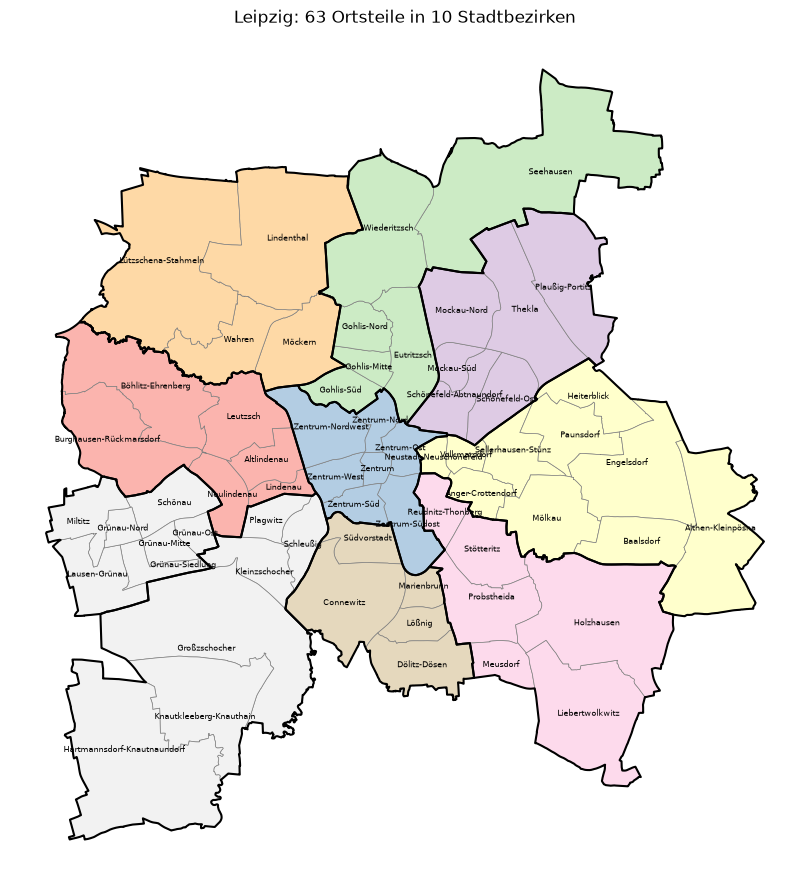

In [9]:
ax = ortsteile.plot(figsize=(11, 11), column="Stadtbezirk", cmap="Pastel1", edgecolor="grey", linewidth=0.5)
bezirke.boundary.plot(ax=ax, color="black", linewidth=1.5)

for _, ot in ortsteile.iterrows():
    punkt = ot.geometry.representative_point()
    ax.annotate(ot["Name"], (punkt.x, punkt.y), ha="center", va="center", fontsize=6)

ax.set_title("Leipzig: 63 Ortsteile in 10 Stadtbezirken")
ax.set_axis_off()

## 5. Interaktive Karte

`explore()` erzeugt eine Karte mit OpenStreetMap im Hintergrund. Sie rechnet die Koordinaten selbst in GPS-Grade um. Zoomen und mit der Maus über einen Ortsteil fahren, um Details zu sehen.

In [10]:
ortsteile.explore(
    column="Stadtbezirk",
    cmap="tab10",
    tooltip=["OT", "Name", "Stadtbezirk", "flaeche_km2"],
    style_kwds={"fillOpacity": 0.35, "weight": 1},
    legend=True,
)

## 6. Die Haltestellen der Linie 8

Die Haltestellen kommen aus dem Fahrplan im GTFS-Format. Das Vorgehen ist dasselbe wie in `test_diagramm.py`:

- **Linie finden** über Nummer *und* Verkehrsunternehmen. Der Feed deckt den ganzen Mitteldeutschen Verkehrsverbund ab, es gibt also z. B. auch eine 8 in Halle.
- **Vorlage-Fahrt wählen:** die längste Haltestellenfolge, die am häufigsten gefahren wird. Kurzfahrten und seltene Varianten fallen so heraus.

`stop_times.txt` ist über 70 MB groß, das Einlesen dauert einen Moment.

In [11]:
LINIE = "8"
UNTERNEHMEN = "Leipziger Verkehrsbetriebe"


def gtfs_lesen(z, datei, **kwargs):
    # Alles als Text lesen, damit IDs wie "00123" nicht zu Zahlen werden
    return pd.read_csv(z.open(datei), dtype=str, encoding="utf-8-sig", **kwargs)


with zipfile.ZipFile(RAW / "gtfs/lvb_gtfs.zip") as z:
    agency = gtfs_lesen(z, "agency.txt")
    routes = gtfs_lesen(z, "routes.txt")
    trips = gtfs_lesen(z, "trips.txt")
    stops = gtfs_lesen(z, "stops.txt")
    stop_times = gtfs_lesen(z, "stop_times.txt", usecols=["trip_id", "stop_id", "stop_sequence"])

agency_ids = agency.loc[agency["agency_name"] == UNTERNEHMEN, "agency_id"]
route = routes[(routes["route_short_name"] == LINIE) & routes["agency_id"].isin(agency_ids)]
assert len(route) == 1, f"Linie {LINIE} nicht eindeutig gefunden"
route

,route_id,agency_id,route_short_name,route_long_name,route_type
246,LVTRAM8,00435,8,StN 8,0


In [12]:
fahrten = trips.loc[trips["route_id"] == route["route_id"].iloc[0], "trip_id"]
halte = stop_times[stop_times["trip_id"].isin(fahrten)].copy()
halte["stop_sequence"] = halte["stop_sequence"].astype(int)
halte = halte.merge(stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]], on="stop_id")
halte = halte.sort_values(["trip_id", "stop_sequence"])

folgen = halte.groupby("trip_id")["stop_name"].apply(tuple)
print(f"{len(folgen)} Fahrten, {folgen.nunique()} verschiedene Haltestellenfolgen")

laengste = folgen[folgen.str.len() == folgen.str.len().max()]
vorlage = laengste.value_counts().index[0]
vorlage_id = laengste[laengste == vorlage].index[0]

strecke = halte[halte["trip_id"] == vorlage_id].reset_index(drop=True)
strecke["position"] = range(1, len(strecke) + 1)
print(f"Linie {LINIE}: {len(strecke)} Haltestellen, {strecke['stop_name'].iloc[0]} → {strecke['stop_name'].iloc[-1]}")

686 Fahrten, 7 verschiedene Haltestellenfolgen
Linie 8: 33 Haltestellen, Leipzig, Grünau-Nord → Leipzig, Paunsdorf Nord


## 7. Haltestellen den Ortsteilen zuordnen

GTFS speichert Koordinaten immer in GPS-Graden (EPSG:4326). Damit wir prüfen können, in welchem Ortsteil eine Haltestelle liegt, rechnen wir die Punkte ins Koordinatensystem der Ortsteile um. Danach findet ein **räumlicher Join** (`sjoin`) für jeden Punkt die Fläche, in der er liegt.

In [13]:
haltestellen = gpd.GeoDataFrame(
    strecke,
    geometry=gpd.points_from_xy(strecke["stop_lon"].astype(float), strecke["stop_lat"].astype(float)),
    crs="EPSG:4326",
).to_crs(ortsteile.crs)

haltestellen = gpd.sjoin(
    haltestellen,
    ortsteile[["OT", "Name", "Stadtbezirk", "geometry"]].rename(columns={"Name": "Ortsteil"}),
    how="left",
    predicate="within",
).drop(columns="index_right")

ohne = haltestellen[haltestellen["Ortsteil"].isna()]
print("Haltestellen ohne Ortsteil:", ohne["stop_name"].tolist() or "keine")
haltestellen[["position", "stop_name", "OT", "Ortsteil", "Stadtbezirk"]]

Haltestellen ohne Ortsteil: keine


,position,stop_name,OT,Ortsteil,Stadtbezirk
0,1,"Leipzig, Grünau-Nord",60,Schönau,West
1,2,"Leipzig, Schönauer Ring",60,Schönau,West
2,3,"Leipzig, Parkallee",60,Schönau,West
3,4,"Leipzig, Grünauer Allee (Bus/Tram)",60,Schönau,West
4,5,"Leipzig, Saarländer Str.",60,Schönau,West
5,6,"Leipzig, Credéstr.",72,Neulindenau,Alt-West
6,7,"Leipzig, Lindenau, Bushof",72,Neulindenau,Alt-West
7,8,"Leipzig, Henriettenstr.",71,Altlindenau,Alt-West
8,9,"Leipzig, Lützner/Merseburger Str.",71,Altlindenau,Alt-West
9,10,"Leipzig, Lindenauer Markt",71,Altlindenau,Alt-West


In [14]:
# Welche Ortsteile durchfährt die Linie, in welcher Reihenfolge, mit wie vielen Halten?
durchfahren = (
    haltestellen.groupby(["OT", "Ortsteil", "Stadtbezirk"], sort=False)
    .agg(erste_position=("position", "min"), haltestellen=("stop_name", "count"))
    .reset_index()
    .sort_values("erste_position")
)
print(f"Die Linie {LINIE} durchfährt {len(durchfahren)} Ortsteile in {durchfahren['Stadtbezirk'].nunique()} Stadtbezirken.")
durchfahren

Die Linie 8 durchfährt 13 Ortsteile in 4 Stadtbezirken.


,OT,Ortsteil,Stadtbezirk,erste_position,haltestellen
0,60,Schönau,West,1,5
1,72,Neulindenau,Alt-West,6,2
2,71,Altlindenau,Alt-West,8,4
3,05,Zentrum-Nordwest,Mitte,12,2
4,04,Zentrum-West,Mitte,14,1
5,00,Zentrum,Mitte,15,2
6,03,Zentrum-Süd,Mitte,16,1
7,01,Zentrum-Ost,Mitte,18,3
8,20,Neustadt-Neuschönefeld,Ost,21,1
9,21,Volkmarsdorf,Ost,22,4


## 8. Die Linie 8 auf der Karte

Ortsteile, durch die die Linie fährt, sind farbig hervorgehoben. Die Strecke ist als gerade Verbindung zwischen den Haltestellen gezeichnet: Der GTFS-Feed enthält keine `shapes.txt` mit dem genauen Gleisverlauf.

In [15]:
auf_der_linie = ortsteile["OT"].isin(durchfahren["OT"])
linie = gpd.GeoDataFrame(
    {"Linie": [LINIE]},
    geometry=[LineString(haltestellen.geometry.tolist())],
    crs=ortsteile.crs,
)

karte = ortsteile[~auf_der_linie].explore(
    color="lightgrey",
    tooltip=["OT", "Name", "Stadtbezirk"],
    style_kwds={"fillOpacity": 0.15, "weight": 0.5},
    name="Übrige Ortsteile",
)
ortsteile[auf_der_linie].explore(
    m=karte,
    column="Name",
    cmap="tab20",
    tooltip=["OT", "Name", "Stadtbezirk"],
    style_kwds={"fillOpacity": 0.4, "weight": 1},
    legend=False,
    name="Ortsteile an der Linie",
)
linie.explore(m=karte, color="#e3000f", style_kwds={"weight": 4}, name=f"Linie {LINIE}")
haltestellen.explore(
    m=karte,
    color="black",
    marker_kwds={"radius": 5},
    tooltip=["position", "stop_name", "Ortsteil"],
    name="Haltestellen",
)

import folium
folium.LayerControl().add_to(karte)
karte

In [16]:
# Optional: Karte als eigene HTML-Datei speichern, die sich im Browser öffnen lässt
karte.save("karte_linie_8.html")

## Was wir gelernt haben

- **63 Ortsteile** teilen **10 Stadtbezirke** lückenlos auf. Die erste Ziffer der Ortsteilnummer ist der Bezirk.
- Die Geodaten sind in Metern (EPSG:25833), GTFS in GPS-Graden (EPSG:4326). Vor jedem räumlichen Vergleich muss umgerechnet werden.
- Die Ortsteile sind sehr unterschiedlich groß. Große Ortsteile am Stadtrand sorgen für „Stufen“, wenn wir Werte entlang der Linie zeigen.
- Für die Verknüpfung mit anderen Daten ist die Nummer `OT` stabiler als der Name.

**Nächster Schritt:** die kleinräumige Statistik in `data/raw/kleinraeumig/` und die Frage, ob sie sich über `OT` oder nur über den Namen verknüpfen lässt.